# Chapter 4

## Adding on to the Quick Start: Switching Out the Dataset with Housing Data Case Study

This notebook is a companion to the book _XGBoost for Regression Predictive Modeling and Time Series Analysis_.
This chapter builds on the work you did in chapter two. In chapter two, you built a model that classified irises by species based on sepal and petal measurements. In this chapter we will build a regression model to predict the cost of a house based on multiple parameters. We will use another famous dataset, the housing data. The intent of this example is to allow you to understand what parts of the code are dataset specific when using XGBoost, and what are the same each time.

## Housing value Predicter

We will be using a dataset that contains information about houses. We will train a model to predict the value of a house based on these characteristics.


# Setting up the python environment and ingesting the housing dataset


In [ ]:
# ----------------------------------------
# filename housingvaluepredicter.ipynb
# purpose predict house value based on
# characteristics such as location, number
# of rooms, number of bedrooms
# author Joyce Weiner
# revision 1.0
# revision history 1.0 - initial script
# ----------------------------------------

import pandas as pd
import numpy as np

In [2]:
# load the California Housing dataset from scikit-learn
from sklearn import datasets

housingX, housingy = datasets.fetch_california_housing(return_X_y=True, as_frame=True)

In [3]:
housingX.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
housingy.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

## Exploring the dataset by making graphs

Next, we want to take a look at the dataset to check for missing data or other problems. To do this we'll make some plots using Seaborn.
Just as before with the iris data, I'm setting the color palette to "dark:grey" so that the output on your screen matches what's printed in the book. While color is fun, it also districts the viewer from the data. According to Edward Tufte, a leading expert in data visualization, we should stive to show the data "above all else" when making graphs.


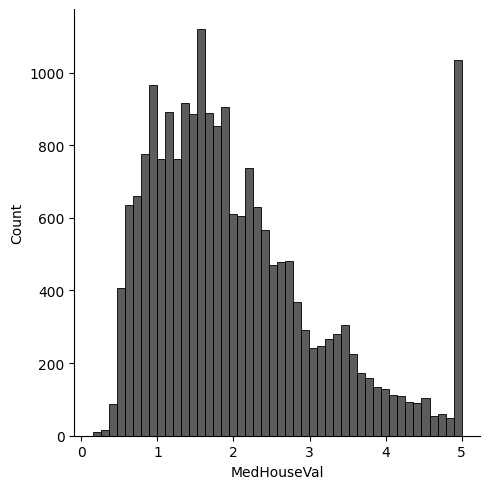

In [5]:
import seaborn as sns

sns.set_palette("dark:grey")

sns.displot(housingy, kind="hist")

## Looking for relationships with x-y plots

Now, we want to see how the data relate to eachother by making some x-y plots. Seaborn makes this very easy to do by offering a function called pairplot.


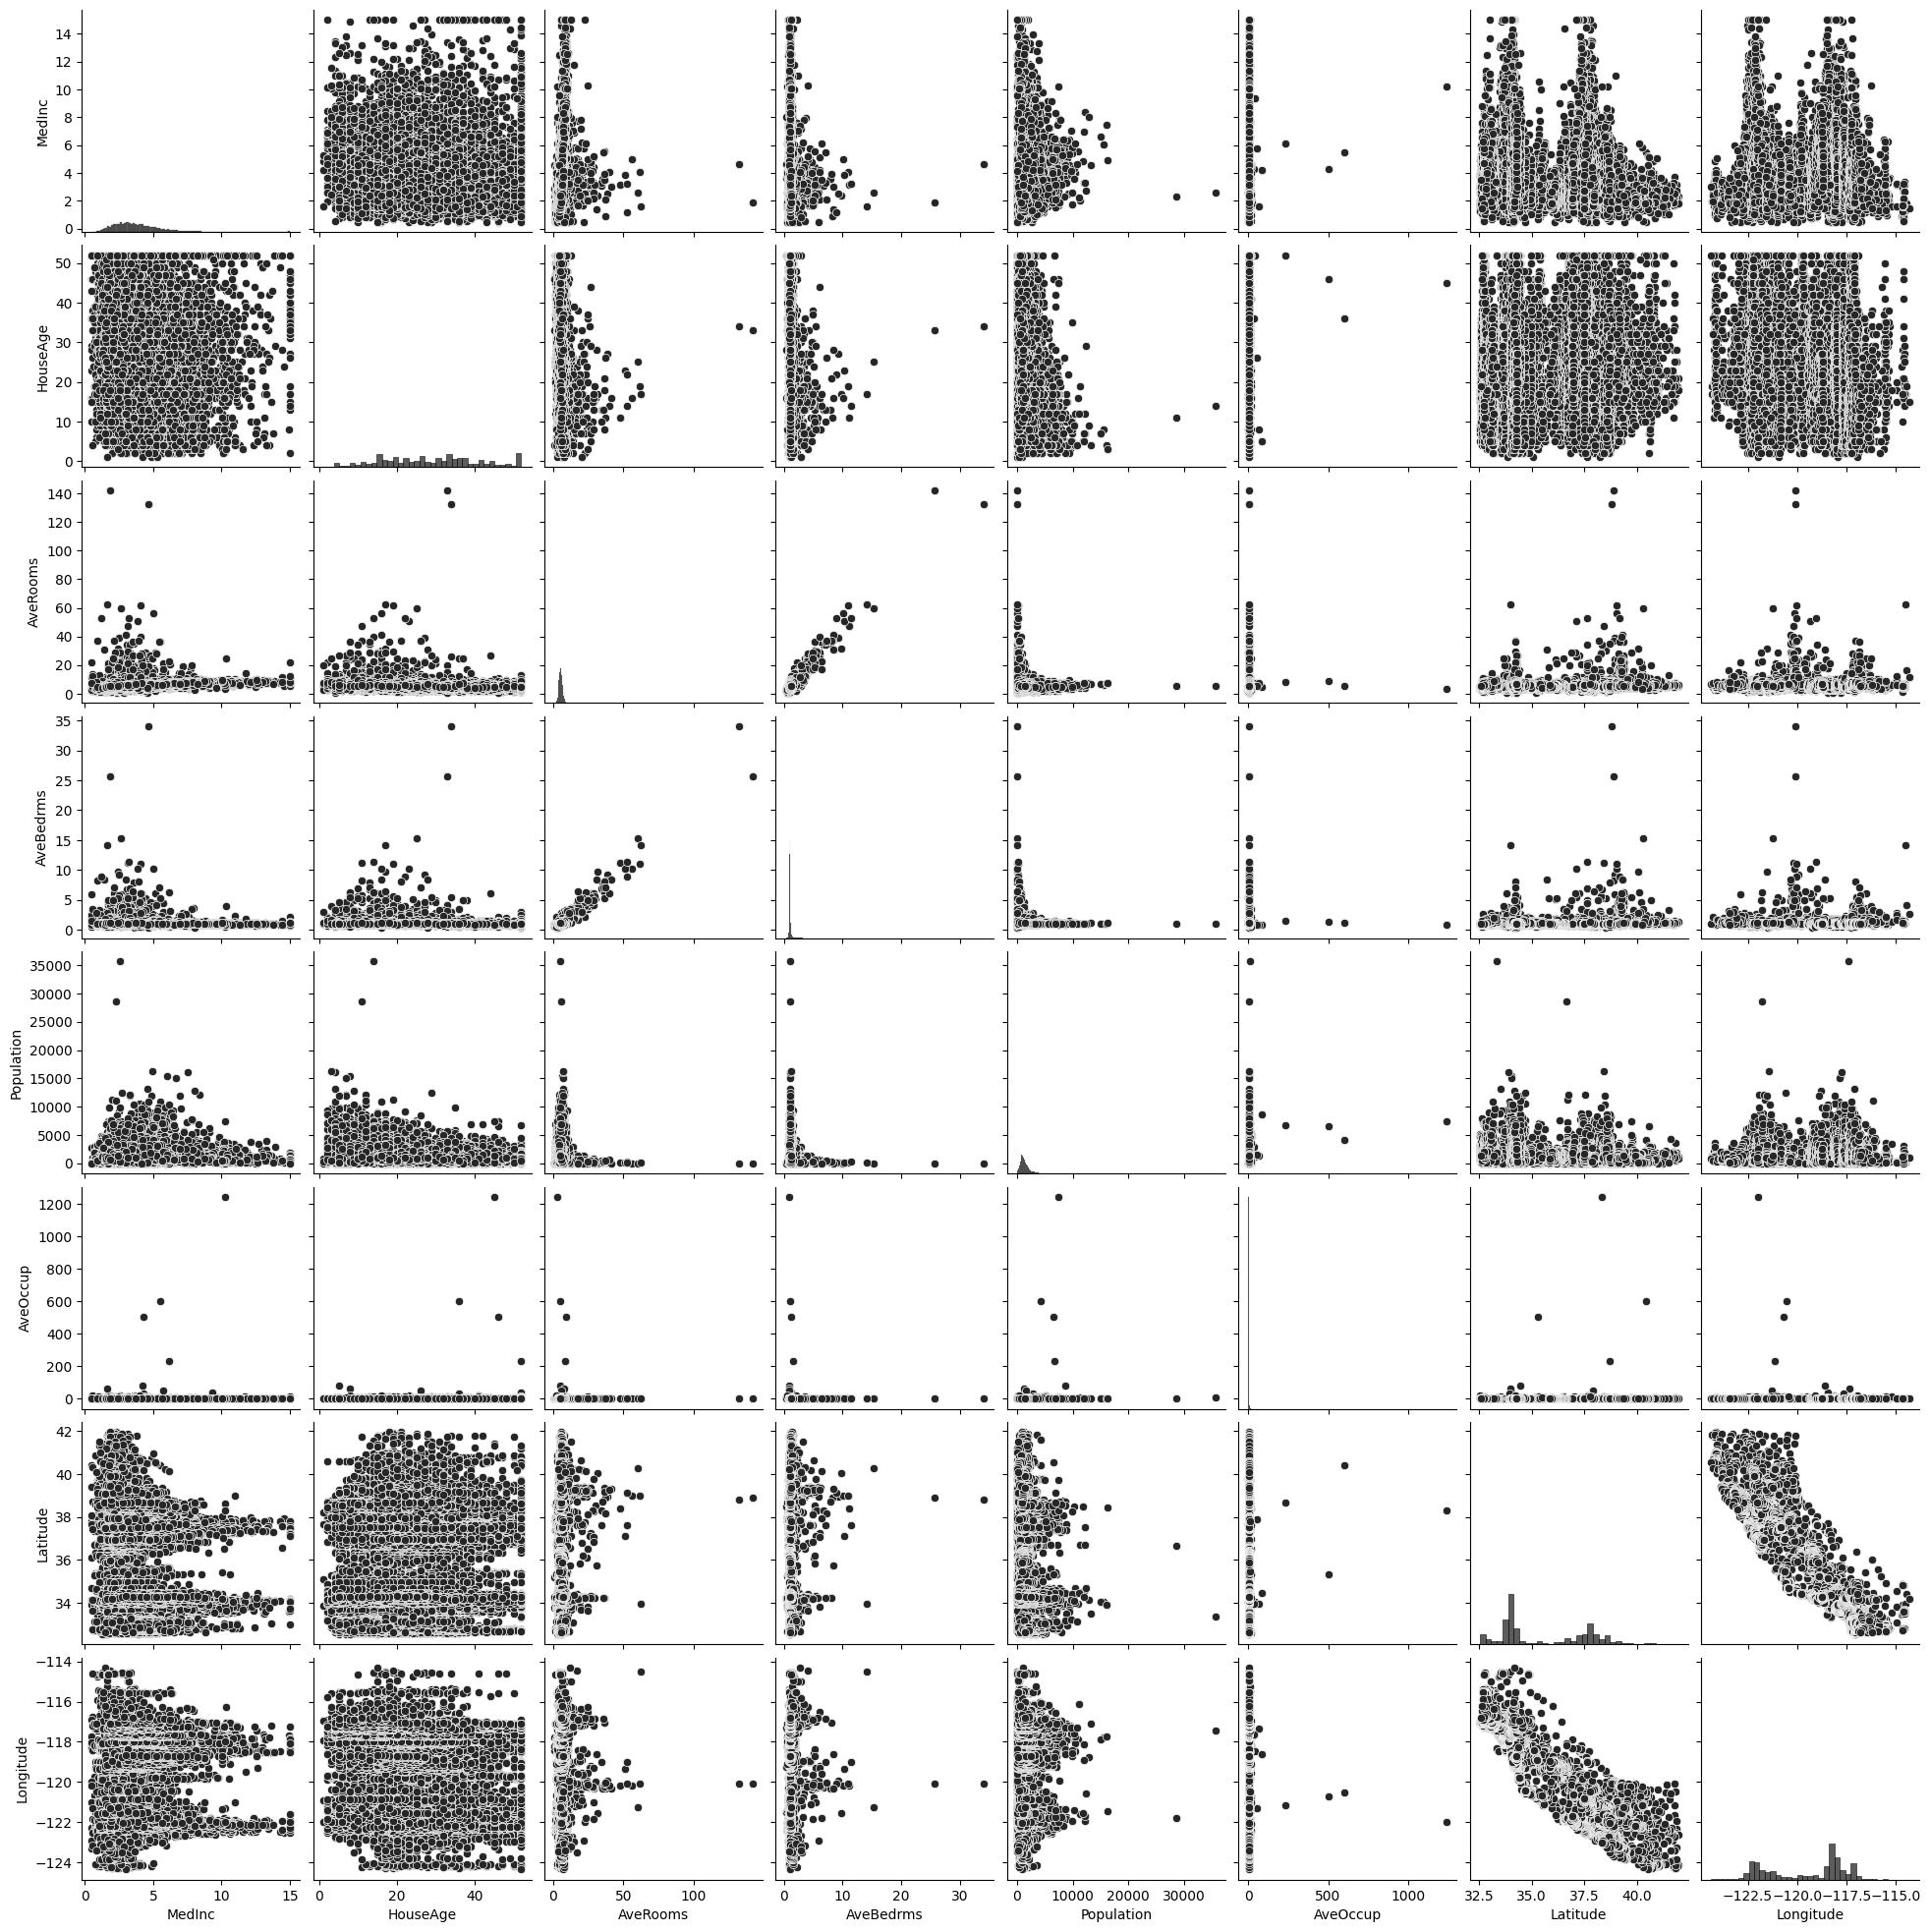

In [6]:
sns.pairplot(housingX)

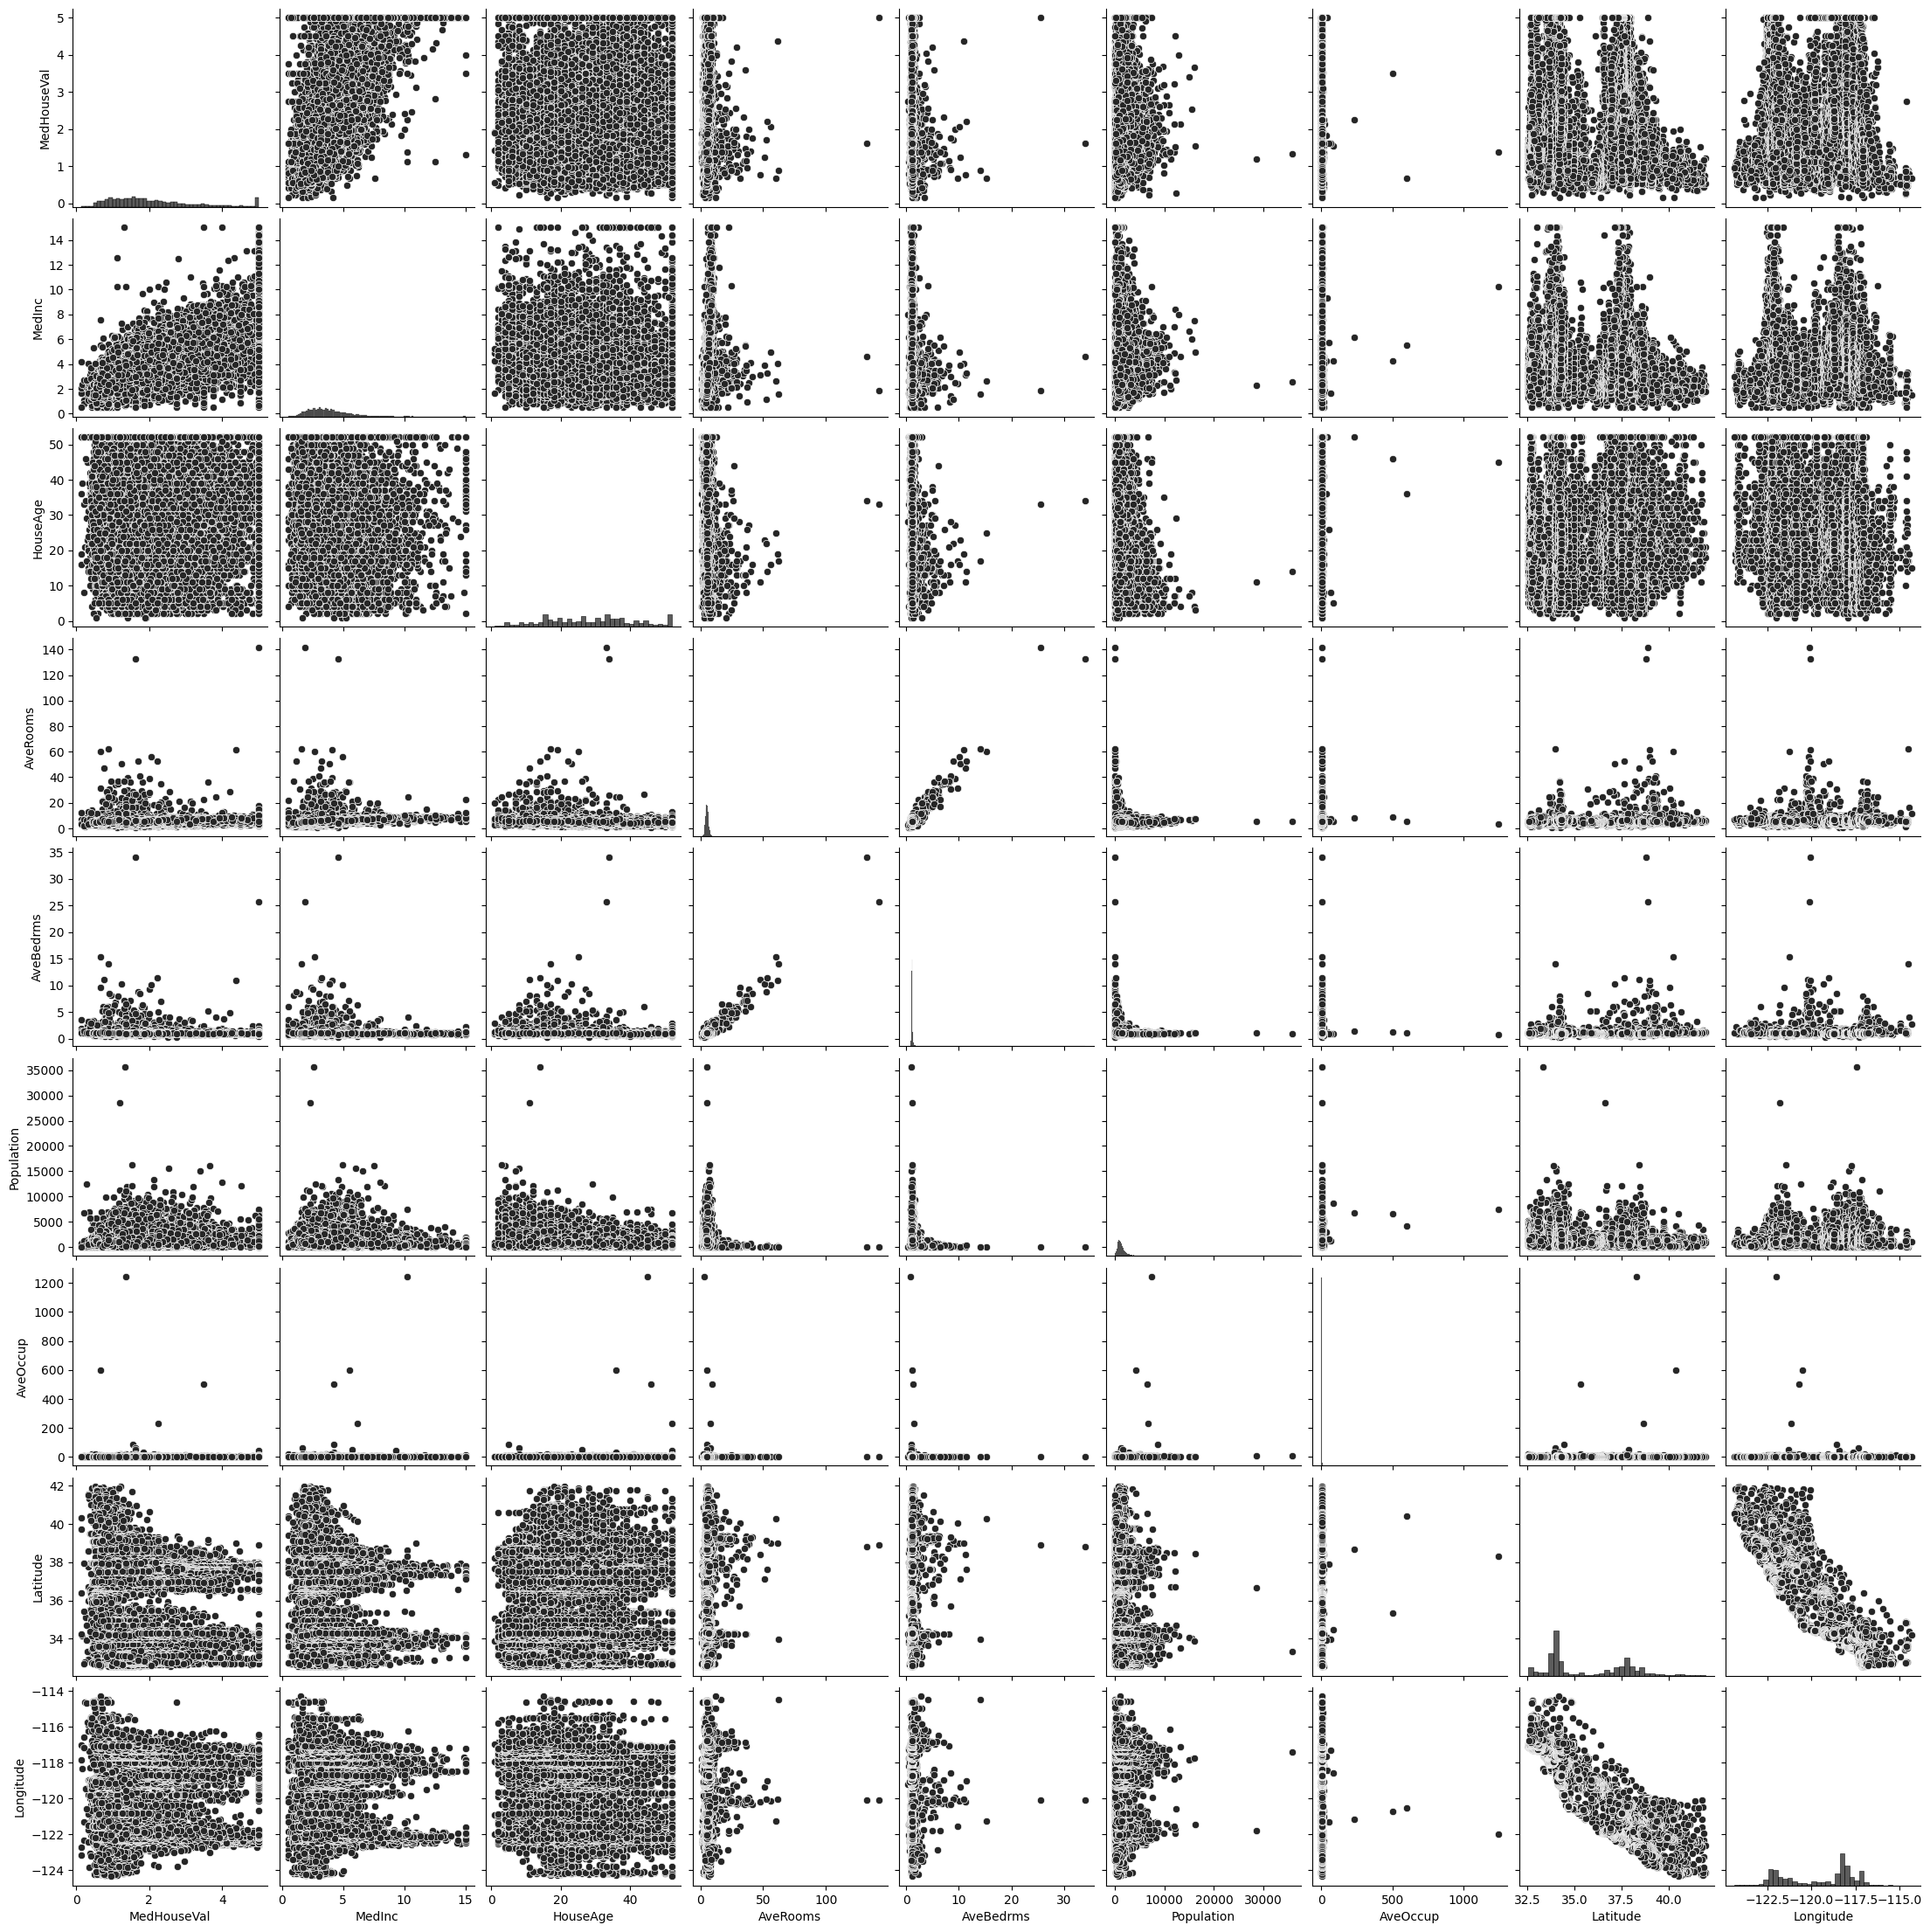

In [7]:
housingxy = pd.concat([housingy, housingX], axis=1)
sns.pairplot(housingxy)

## Data preparation

Next, we'll split the data into training and test sets using the scikit-learn train_test_split function


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    housingX, housingy, test_size=0.2, random_state=17
)

In [9]:
X_train.shape

(16512, 8)

In [10]:
X_test.shape

(4128, 8)

In [11]:
y_train.shape

(16512,)

In [12]:
y_test.shape

(4128,)

In [13]:
X_test.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
18403,5.4741,24.0,6.587799,1.060181,4017.0,3.311624,37.24,-121.84
13405,1.9583,7.0,5.362805,1.442073,1064.0,3.243902,34.10,-117.46
9539,2.6058,40.0,3.885714,0.914286,785.0,4.485714,37.39,-120.71
8668,4.5817,30.0,4.146135,1.108696,1526.0,1.842995,33.82,-118.39
9019,8.0137,9.0,7.734673,1.041211,12873.0,3.274739,34.16,-118.78


Next, we'll set up XGBoost to perform a prediction using regression.


## XGBoost model settings and model training


In [14]:
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

housevalue_regressor = xgb.XGBRegressor()

housevalue_regressor.fit(
    X_train, y_train, eval_set=[(X_test, y_test), (X_train, y_train)]
)

[0]	validation_0-rmse:0.93417	validation_1-rmse:0.93744
[1]	validation_0-rmse:0.80544	validation_1-rmse:0.79501
[2]	validation_0-rmse:0.72406	validation_1-rmse:0.70244
[3]	validation_0-rmse:0.66749	validation_1-rmse:0.63818
[4]	validation_0-rmse:0.63751	validation_1-rmse:0.60033
[5]	validation_0-rmse:0.61189	validation_1-rmse:0.56644
[6]	validation_0-rmse:0.58620	validation_1-rmse:0.53308
[7]	validation_0-rmse:0.57241	validation_1-rmse:0.51228
[8]	validation_0-rmse:0.56593	validation_1-rmse:0.50156
[9]	validation_0-rmse:0.55121	validation_1-rmse:0.48426
[10]	validation_0-rmse:0.54240	validation_1-rmse:0.47137
[11]	validation_0-rmse:0.53708	validation_1-rmse:0.46342
[12]	validation_0-rmse:0.53323	validation_1-rmse:0.45607
[13]	validation_0-rmse:0.53001	validation_1-rmse:0.45001
[14]	validation_0-rmse:0.52530	validation_1-rmse:0.44200
[15]	validation_0-rmse:0.52239	validation_1-rmse:0.43719
[16]	validation_0-rmse:0.52073	validation_1-rmse:0.43158
[17]	validation_0-rmse:0.51860	validation

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Making a prediction using XGBoost

Now our model is trained, and we can use it to classify irises based on their measurements. Let's test out how well it does on our test dataset. We use the predict method and pass it the X_test data.


In [15]:
y_score = housevalue_regressor.predict(X_test)

Use the model with example data not in the test or training set (inference).


In [16]:
X_example = np.array([12.5, 10, 9, 3, 4000, 3, 33.98, -118.45])
X_example = X_example.reshape(1, 8)
y_example = housevalue_regressor.predict(X_example)
y_example

array([5.4786406], dtype=float32)

That's all we need to do to use the model.
Now, we look at how well the model is working.


In [17]:
predicter_r2 = r2_score(y_true=y_test, y_pred=y_score)
predicter_r2

0.8167135465189188

To do RMSE we need to take the square root of the mean_squared_error, which you get by using the squared=False option in the mean_squared_error function.


In [18]:
predicter_rmse = root_mean_squared_error(y_true=y_test, y_pred=y_score)
predicter_rmse

0.48955245051753077

Our R2 is pretty good and the RMSE is middle of the range (lower is better). Let's plot the modeled values, the actuals and the residuals.


<Axes: xlabel='MedHouseVal'>

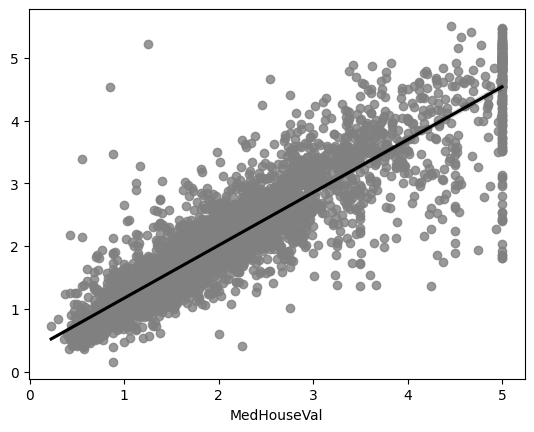

In [19]:
sns.regplot(
    x=y_test, y=y_score, scatter_kws={"color": "grey"}, line_kws={"color": "black"}
)

To wrap this up, let's calculate and plot the residuals


In [20]:
residuals = y_test - y_score
residuals

18403   -0.443082
13405    0.097641
9539    -0.005543
8668     0.735812
9019    -0.051286
           ...   
10696   -0.091547
20360   -0.023798
10281    0.741597
7092    -0.059211
3219    -0.080658
Name: MedHouseVal, Length: 4128, dtype: float64

Visualize the residuals. First combine X_test and the residuals into one dataframe, then plot the residuals against each x parameter in a row of eight x-y scatter plots.


In [21]:
X_testResiduals = pd.concat([X_test, residuals], axis=1)

In [22]:
X_testResiduals.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
18403,5.4741,24.0,6.587799,1.060181,4017.0,3.311624,37.24,-121.84,-0.443082
13405,1.9583,7.0,5.362805,1.442073,1064.0,3.243902,34.10,-117.46,0.097641
9539,2.6058,40.0,3.885714,0.914286,785.0,4.485714,37.39,-120.71,-0.005543
8668,4.5817,30.0,4.146135,1.108696,1526.0,1.842995,33.82,-118.39,0.735812
9019,8.0137,9.0,7.734673,1.041211,12873.0,3.274739,34.16,-118.78,-0.051286


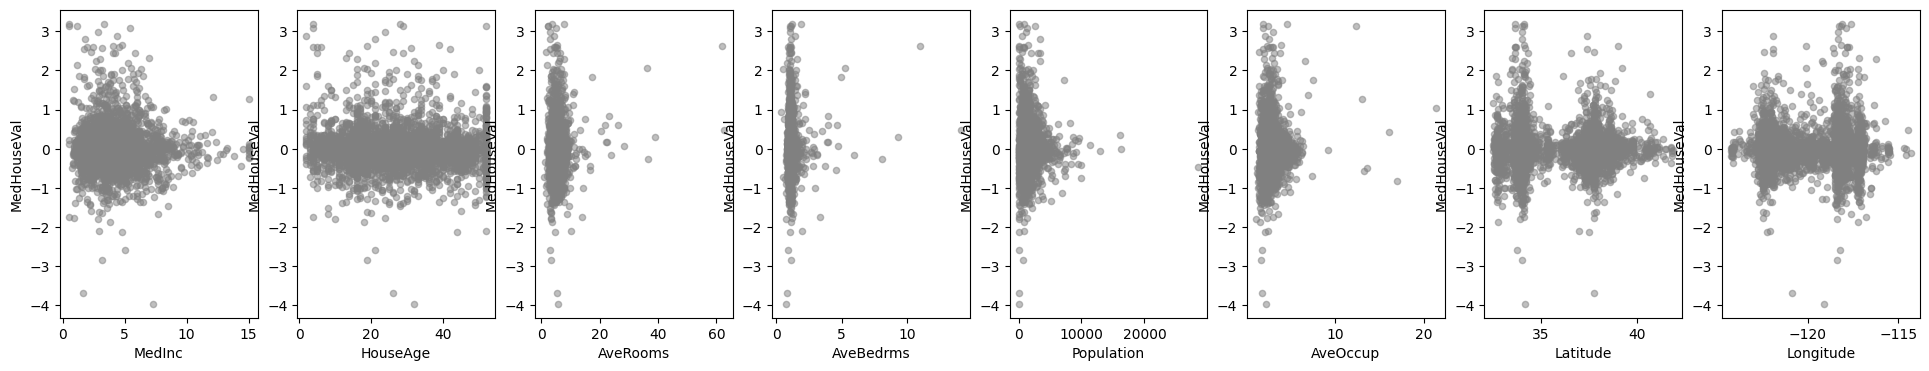

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=8, figsize=(24, 4))

for xcol, ax in zip(X_test.loc[:].columns, axes):
    X_testResiduals.plot(
        kind="scatter", x=xcol, y="MedHouseVal", ax=ax, alpha=0.5, color="grey", c=None
    )

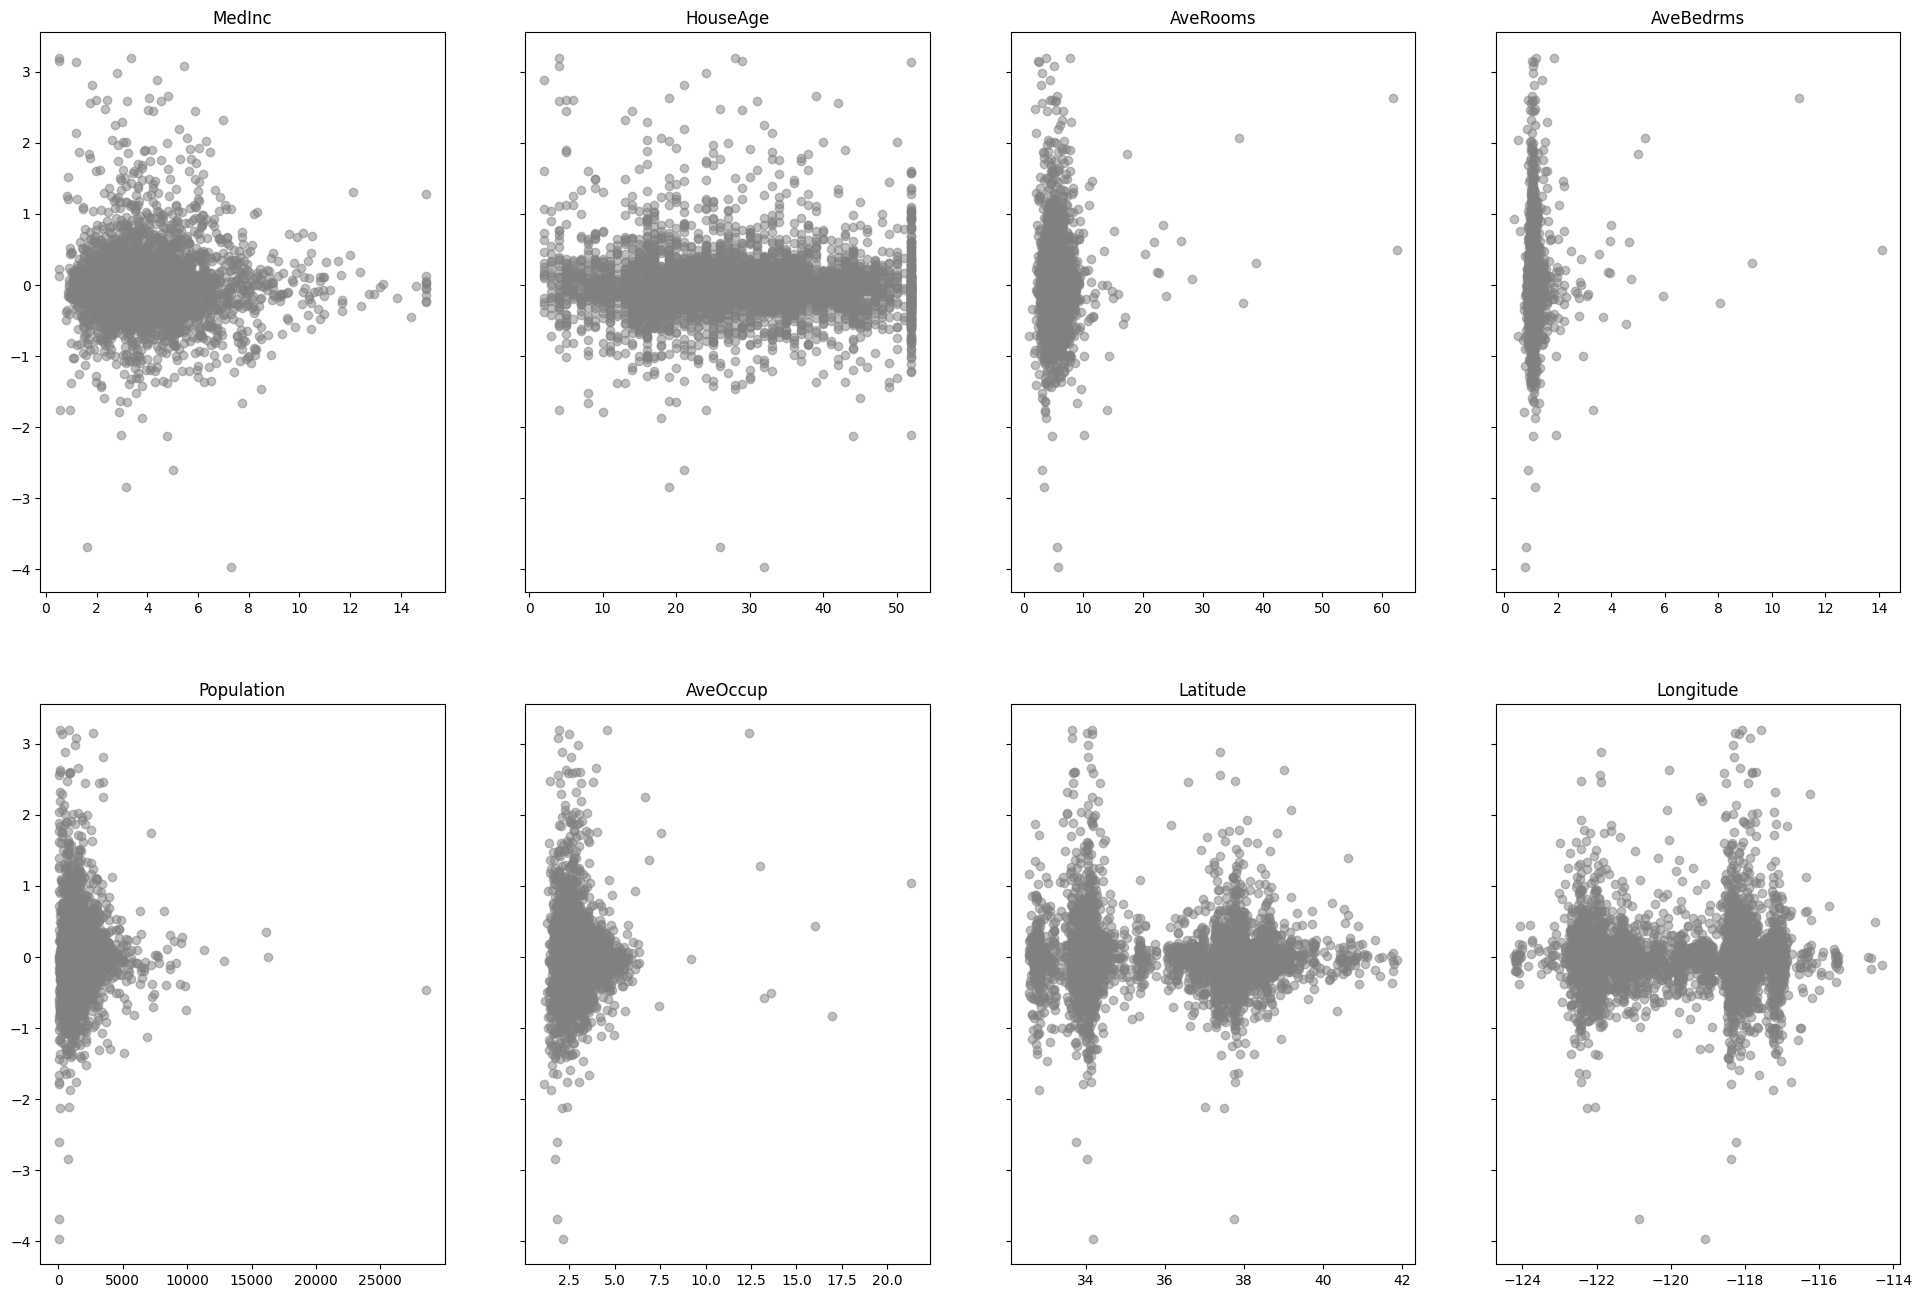

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 16), sharey=True)
feature_cols = X_testResiduals.columns[:-1]  # Exclude 'MedHouseVal' (residuals column)
for i, col in enumerate(feature_cols):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]
    ax.scatter(
        x=X_testResiduals[col],
        y=X_testResiduals["MedHouseVal"],
        alpha=0.5,
        color="grey",
    )
    ax.set_title(col)